In [1]:
# resnet models
from tensorflow.keras.applications.resnet import ResNet50, ResNet101, ResNet152, preprocess_input, decode_predictions
import tensorflow as tf
from tensorflow import keras
# VGG models
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg19 import VGG19

# inception
from tensorflow.keras.applications.inception_v3 import InceptionV3

# tensorflow and keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import ops
import glob
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Training/Validation dataset loading and data paths loading for inference

I use image_dataset_from_directory to resize all images to 224 x 224 pixels and split the data into training and validation sets.


In [2]:
# dataset class name getting
dataset_path = Path("/content/drive/MyDrive/BMET5933/WEEK_10/hep2imgcnn")
# store class names in a list
dataset_classes = [folder.name for folder in dataset_path.iterdir() if folder.is_dir()]

# dataset config
BATCH_SIZE = 32
SEED = 42

# create training dataset
train_ds = keras.utils.image_dataset_from_directory(
    dataset_path,
    labels = 'inferred',
    label_mode = 'int',
    validation_split = 0.2,
    subset = 'training',
    seed = SEED,
    image_size = (224, 224),
    batch_size = BATCH_SIZE
)

# create validation dataset
val_ds = keras.utils.image_dataset_from_directory(
    dataset_path,
	labels = 'inferred',
	label_mode = 'int',
	validation_split = 0.2,
	subset = 'validation',
	seed = SEED,
	image_size = (224, 224),
	batch_size = BATCH_SIZE
)

# store image paths for image inference
image_paths = []
for class_name in dataset_classes:
    class_path_list = sorted(glob.glob(str(dataset_path / class_name / "*.png")))
    image_paths.extend(class_path_list)

Found 428 files belonging to 5 classes.
Using 343 files for training.
Found 428 files belonging to 5 classes.
Using 85 files for validation.


# Useful funcs for this lab

In [3]:
# func for load original image
def load_image(image_path, target_size=(224, 224)):
	loaded_img = keras_image.load_img(image_path, target_size=target_size)
	return loaded_img

# func for loading and preprocessing an image for inference
def preprocess_image(img_path, target_size=(224, 224)):

	# load image and convert to np array
	loaded_img = keras_image.load_img(img_path, target_size=target_size)
	img_array = keras_image.img_to_array(loaded_img)

	# add batch dimension and preprocess the image for the model
	img_array = np.expand_dims(img_array, axis=0)
	img_array = preprocess_input(img_array)
	return img_array

# func to decode predictions and print
def pred_decode(preds):
	# decode predictions of top k
	pred = decode_predictions(preds, top=3)[0]

	print("Top-k predicted classes and probabilities:")
	# print the top-k predicted classes and probabilities
	for rank, (_, class_name, prob) in enumerate(pred, start=1):
		print(f"{rank}. {class_name}: {prob:.4f}")
	return pred

# func to perform inference on an image
def image_inference(model, img, top_k=3):
	# Run the model and return the raw prediction scores.
	preds = model.predict(img)

	# print the top-k predicted classes and probabilities
	pred_decode(preds)
	return preds

# Model loading and model summary

I selected ResNet50 as the pre-trained ImageNet model. The full ImageNet model takes 224 x 224 RGB images and produces probabilities over 1000 ImageNet classes.

In [4]:
# initialize resnet50 model with imagenet weights
resnet50_model = ResNet50(weights='imagenet')

# create a new model that outputs the features from the 'avg_pool' layer of ResNet50
resnet50_tl_model = Model(inputs = resnet50_model.input, outputs = resnet50_model.get_layer('avg_pool').output)

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# summary ResNet50 model architecture
resnet50_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

# Plot original and preprocessed version of image

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

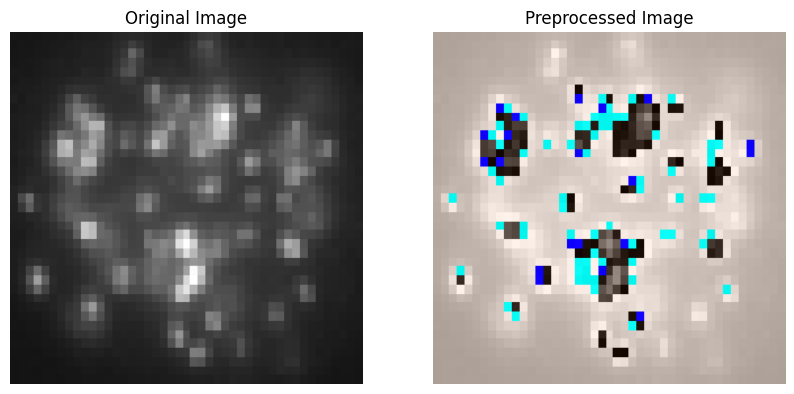

In [6]:
original_image = load_image(image_paths[0])
preprocessed_image = preprocess_image(image_paths[0])

# plot original image and preprocessed image
# 	create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# 	plot original image
axes[0].imshow(original_image)
axes[0].set_title("Original Image")
axes[0].axis('off')

# 	plot preprocessed image
axes[1].imshow(preprocessed_image[0].astype('uint8'))
axes[1].set_title("Preprocessed Image")
axes[1].axis('off')

# Prediction without training

Here I test the ResNet50 model on one cell image before training on the HEp-2 dataset. The predicted labels are ImageNet labels, not cell pattern labels.


In [7]:
# inferencing with ResNet50 model
preds = image_inference(resnet50_model, preprocessed_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Top-k predicted classes and probabilities:
1. window_screen: 0.9657
2. window_shade: 0.0038
3. analog_clock: 0.0026


# Feature extractor

In this section, ResNet50 is used as a fixed feature extractor. Each image is converted into a 2048-dimensional feature vector.


In [8]:
all_train_image_features = []
for img_path in train_ds.file_paths:
  # load and preprocess the image
  preprocessed_image = preprocess_image(img_path)
  # extract features using the ResNet50 model
  images_features = resnet50_tl_model.predict(preprocessed_image)
  # store the extracted features in the list
  all_train_image_features.append(images_features)

# concatenate to np feature matrix along first dim
train_features = np.concatenate(all_train_image_features, axis=0)


# repeat the same process for validation dataset
all_val_image_features = []
for image_path in val_ds.file_paths:
  # load and preprocess the image
  preprocessed_image = preprocess_image(image_path)
  # extract features using the ResNet50 model
  images_features = resnet50_tl_model.predict(preprocessed_image)
  # store the extracted features in the list
  all_val_image_features.append(images_features)

val_features = np.concatenate(all_val_image_features, axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━

# Classification by SVM

Here standardScaler normalizes the feature values before SVM training, because SVM is sensitive to feature scale. In the saved run, the SVM reached a validation accuracy of about 0.8588.

chatgpt5.5 used here for reviewing and suggesting how to combine CNN features with SVM.


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import make_pipeline

In [10]:
label_encoder = LabelEncoder()

class_names = train_ds.class_names
class_to_label = {class_name: i for i, class_name in enumerate(class_names)}

# read labels from training dataset and concatenate to a single array
train_labels = np.array([class_to_label[Path(image_path).parent.name] for image_path in train_ds.file_paths])
train_labels = label_encoder.fit_transform(train_labels)

# read labels from validation dataset and concatenate to a single array
val_labels = np.array([class_to_label[Path(image_path).parent.name] for image_path in val_ds.file_paths])
val_labels = label_encoder.transform(val_labels)

# train SVM classifier on the extracted features
svm_model  = make_pipeline(StandardScaler(),
                          SVC(kernel = 'rbf', C=1, gamma='scale', random_state=SEED))
svm_model.fit(train_features, train_labels)

print("SVM classifier trained on ResNet50 features.")

# predict on validation set
val_pred = svm_model.predict(val_features)
print('SVM validation accuracy:', accuracy_score(val_labels, val_pred))
print('Classification Report:\n', classification_report(val_labels, val_pred, target_names=class_names))
print('confusion matrix:\n', confusion_matrix(val_labels, val_pred))

SVM classifier trained on ResNet50 features.
SVM validation accuracy: 0.8588235294117647
Classification Report:
                  precision    recall  f1-score   support

     centromere       0.92      0.86      0.89        14
coarse_speckled       1.00      0.85      0.92        13
  fine_speckled       0.69      1.00      0.82        18
    homogeneous       0.83      0.71      0.77        21
      nucleolar       1.00      0.89      0.94        19

       accuracy                           0.86        85
      macro avg       0.89      0.86      0.87        85
   weighted avg       0.88      0.86      0.86        85

confusion matrix:
 [[12  0  2  0  0]
 [ 0 11  0  2  0]
 [ 0  0 18  0  0]
 [ 0  0  6 15  0]
 [ 1  0  0  1 17]]


# Fine-tuning a CNN

This section builds a CNN classifier by attaching a new classification head to a pre-trained ResNet50 backbone. Most ResNet50 layers are frozen and only the last layers are allowed to train, which reduces overfitting on this small dataset while still adapting some high-level features to the cell images.

chatgpt5.5 used here for suggesting how to reduce overfitting, the original unfrozen version for all layers can only get around 40% accuracy. It also used to polish analyzation.


In [11]:
# fine-tuning the ResNet50 model classification head
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
# allow for train fearure extraction layers
base_model.trainable = True

# freeze layer except the last 20
for layer in base_model.layers[:-20]:
	layer.trainable = False

# build the fine-tuning model
inputs = keras.Input(shape=(224, 224, 3))
# preprocess the input for the ResNet50 model
preprocessed = preprocess_input(inputs)
# extract features using the base model
features = base_model(preprocessed, training=False)
# add global average pooling layer and a dense output layer for classification
pooling_layer = layers.GlobalAveragePooling2D()
# add a dense output layer for classification
pooled = pooling_layer(features)
# add a dense output layer for classification
outputs = layers.Dense(len(class_names), activation="softmax")(pooled)

# write custome layer into model
fine_tune_model = keras.Model(inputs, outputs)

# training config
fine_tune_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = fine_tune_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.7493 - loss: 0.7193 - val_accuracy: 0.6118 - val_loss: 6.1438
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.9038 - loss: 0.3740 - val_accuracy: 0.4824 - val_loss: 173.6001
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - accuracy: 0.9417 - loss: 0.3601 - val_accuracy: 0.4706 - val_loss: 64.7644
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.9534 - loss: 0.1509 - val_accuracy: 0.5059 - val_loss: 34.9098
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.9767 - loss: 0.0983 - val_accuracy: 0.5059 - val_loss: 19.6587
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.9621 - loss: 0.0931 - val_accuracy: 0.7647 - val_loss: 5.4103
Epoch 7/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - accuracy: 0.9738 - loss: 0.0839 - val_accuracy: 0.7647 - val_loss: 5.1799
Epoch 8/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/ste

The saved fine-tuning run shows that the CNN can learn the HEp-2 classes, but the validation accuracy changes noticeably between epochs. This is expected because the dataset is small and the validation set has only 85 images. In the saved output, the best validation accuracy reached about 0.8706, while the final epoch was lower.


# Fine-tuning with Data Augmentation

This section repeats the CNN fine-tuning experiment with data augmentation.

chatgpt5.5 used here for learning and suggesting how to introduce datagumentation.


In [12]:
# define data augmentation pipeline
data_agumentation = keras.Sequential(
	[
		layers.RandomFlip("horizontal"),
		layers.RandomRotation(0.1),
		layers.RandomZoom(0.1),
	]
)

new_baseline_model = ResNet50(
    weights = 'imagenet',
    include_top = False,
	input_shape = (224, 224, 3)
)

# allowing for training of the fearure extractors
new_baseline_model.trainable = True

for layer in new_baseline_model.layers[0:-20]:
    layer.trainable = False

# define a new model with data augmentation and the same base model
# preprocess the input for the ResNet50 model, then apply data augmentation, and then extract features using the base model
aug_inputs = keras.Input(shape=(224, 224, 3))
# data augmentation
augmented = data_agumentation(aug_inputs)
# preprocess the input for the ResNet50 model
aug_preprocessed = preprocess_input(augmented)
# extract features using the base model
features = new_baseline_model(aug_preprocessed, training=True)
# pooling and output layer
pooled = pooling_layer(features)
aug_outputs = layers.Dense(len(class_names), activation="softmax")(pooled)

# write custome layer into model
aug_fine_tune_model = keras.Model(aug_inputs, aug_outputs)

# training config
aug_fine_tune_model.compile(
	optimizer=keras.optimizers.Adam(learning_rate=0.001),
	loss="sparse_categorical_crossentropy",
	metrics=["accuracy"]
)

# train
aug_history = aug_fine_tune_model.fit(
    train_ds,
    validation_data=val_ds,
	epochs=15
)

Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 23s 781ms/step - accuracy: 0.7347 - loss: 0.8116 - val_accuracy: 0.5412 - val_loss: 11.3520
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 236ms/step - accuracy: 0.8892 - loss: 0.3580 - val_accuracy: 0.4353 - val_loss: 51.2886
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 243ms/step - accuracy: 0.8950 - loss: 0.3748 - val_accuracy: 0.4000 - val_loss: 49.5317
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step - accuracy: 0.9184 - loss: 0.2503 - val_accuracy: 0.5412 - val_loss: 22.0921
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 294ms/step - accuracy: 0.9504 - loss: 0.1631 - val_accuracy: 0.5882 - val_loss: 9.5071
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 266ms/step - accuracy: 0.9446 - loss: 0.1942 - val_accuracy: 0.7412 - val_loss: 2.8676
Epoch 7/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 234ms/step - accuracy: 0.9417 - loss: 0.2472 - val_accuracy: 0.7176 - val_loss: 2.2397
Epoch 8/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 253ms/step - accuracy: 0.9504 - loss: 0.1706 - val_accura

The augmented model tests whether random image transformations improve generalization. In training progress, the best validation accuracy reached about 0.8824, although the final epoch was lower.


# Result Comparison and Discussion

| Method | Validation result in saved run |
|---|---:|
| ResNet50 features + SVM | 0.8588 accuracy |
| Fine-tuned ResNet50 | best validation accuracy about 0.8706 |
| Fine-tuned ResNet50 with augmentation | best validation accuracy about 0.8824 |



In [16]:
!apt-get update
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc
!jupyter nbconvert --to pdf /content/drive/MyDrive/BMET5933/WEEK_11/Week11_code.ipynb

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages